In [ ]:
#full regression model with heteroskedasticity-robust standard errors
import pandas as pd
import statsmodels.api as sm

file_path = "RioTintoData.xlsx"
# Load the data from the Excel file
df = pd.read_excel(file_path, sheet_name="Monthly_Returns")

for col in df.columns:
    if col != "Month_end":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna()

print("Sample size after dropna: ", len(df_clean))

# Define the dependent variable (Y) and independent variable (X)
Y = df_clean["r_RIO"]

X = df_clean[[
    "r_IronOre",
    "r_Copper",
    "r_Aluminum",
    "r_AUDUSD",
    "r_SPX"
]]

# Add a constant to the independent variables
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(Y, X).fit(cov_type='HC3')


# Print the regression results
print(model.summary())

Sample size after dropna:  170
                            OLS Regression Results                            
Dep. Variable:                  r_RIO   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     47.99
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           2.10e-30
Time:                        20:20:46   Log-Likelihood:                 273.82
No. Observations:                 170   AIC:                            -535.6
Df Residuals:                     164   BIC:                            -516.8
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0093

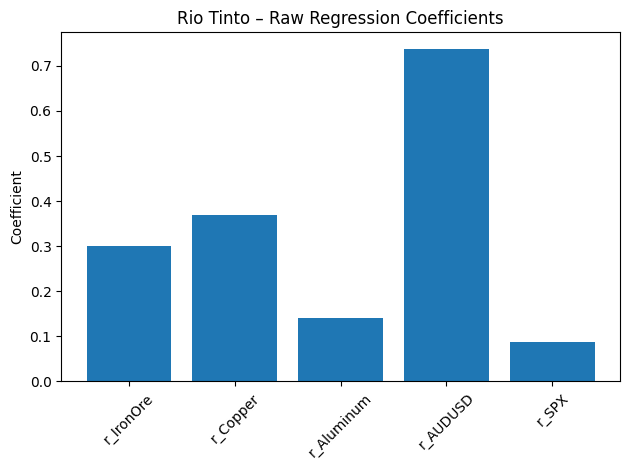

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract coefficients (exclude constant)
coef = model.params.drop("const")

plt.figure()
plt.bar(coef.index, coef.values)
plt.title("Rio Tinto – Raw Regression Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Full_Model_Raw_Betas.png", dpi=300)
plt.show()

In [ ]:
#Reduced regression showing the effect of iron ore and copper while removing FX and SPX
import pandas as pd
import statsmodels.api as sm

file_path = "RioTintoData.xlsx"
# Load the data from the Excel file
df = pd.read_excel(file_path, sheet_name="Monthly_Returns")

for col in df.columns:
    if col != "Month_end":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna()

print("Sample size after dropna: ", len(df_clean))

# Define the dependent variable (Y) and independent variable (X)
Y = df_clean["r_RIO"]

X2 = df_clean[["r_IronOre", "r_Copper"]]
X2 = sm.add_constant(X2)
# Fit the OLS regression model
model2 = sm.OLS(Y, X2).fit(cov_type='HC3')
# Print the regression results
print(model2.summary())


Sample size after dropna:  170
                            OLS Regression Results                            
Dep. Variable:                  r_RIO   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     77.64
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.44e-24
Time:                        20:33:17   Log-Likelihood:                 258.94
No. Observations:                 170   AIC:                            -511.9
Df Residuals:                     167   BIC:                            -502.5
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0080

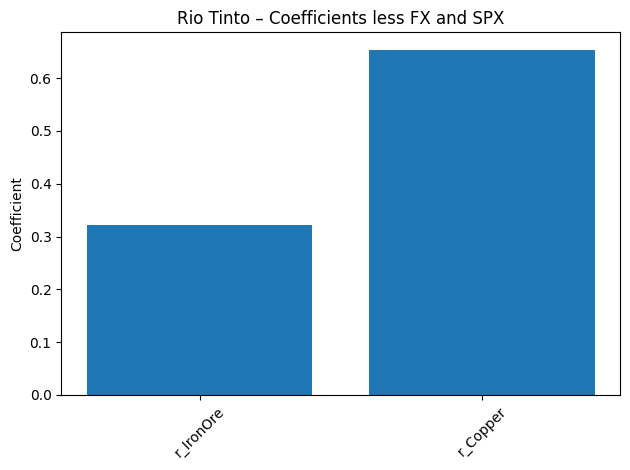

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract coefficients (exclude constant)
coef = model2.params.drop("const")

plt.figure()
plt.bar(coef.index, coef.values)
plt.title("Rio Tinto – Coefficients less FX and SPX")
plt.ylabel("Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Coefficients_less_FX_and_SPX.png", dpi=300)
plt.show()


In [ ]:
#Show the correlation matrix for the independent variables
import pandas as pd
import statsmodels.api as sm

file_path = "RioTintoData.xlsx"
# Load the data from the Excel file
df = pd.read_excel(file_path, sheet_name="Monthly_Returns")

for col in df.columns:
    if col != "Month_end":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna()

print("Sample size after dropna: ", len(df_clean))

# Define the dependent variable (Y) and independent variable (X)
Y = df_clean["r_RIO"]

X2 = df_clean[["r_IronOre", "r_Copper", "r_Aluminum", "r_AUDUSD", "r_SPX"]].corr()
print(X2)

Sample size after dropna:  170
            r_IronOre  r_Copper  r_Aluminum  r_AUDUSD     r_SPX
r_IronOre    1.000000  0.383068    0.246436  0.306347  0.108870
r_Copper     0.383068  1.000000    0.600838  0.552529  0.391007
r_Aluminum   0.246436  0.600838    1.000000  0.455000  0.307888
r_AUDUSD     0.306347  0.552529    0.455000  1.000000  0.550182
r_SPX        0.108870  0.391007    0.307888  0.550182  1.000000


In [31]:
#Standardized betas
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


file_path = "RioTintoData.xlsx"
# Load the data from the Excel file
df = pd.read_excel(file_path, sheet_name="Monthly_Returns")

for col in df.columns:
    if col != "Month_end":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna()

print("Sample size after dropna: ", len(df_clean))

# Select variables
X_vars = ["r_IronOre","r_Copper","r_AUDUSD","r_SPX"]

# Standardize X
scaler_X = StandardScaler()
X_std_array = scaler_X.fit_transform(df_clean[X_vars])
X_std = pd.DataFrame(X_std_array, columns=X_vars)

# Standardize Y
scaler_Y = StandardScaler()
Y_std = scaler_Y.fit_transform(df_clean[["r_RIO"]])
Y_std = pd.Series(Y_std.flatten(), name="r_RIO")

# Add constant
X_std = sm.add_constant(X_std)

# Run regression
model_std = sm.OLS(Y_std, X_std).fit(cov_type='HC3')

print(model_std.summary())

Sample size after dropna:  170
                            OLS Regression Results                            
Dep. Variable:                  r_RIO   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     58.04
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.66e-30
Time:                        21:26:12   Log-Likelihood:                -157.77
No. Observations:                 170   AIC:                             325.5
Df Residuals:                     165   BIC:                             341.2
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.765e-17

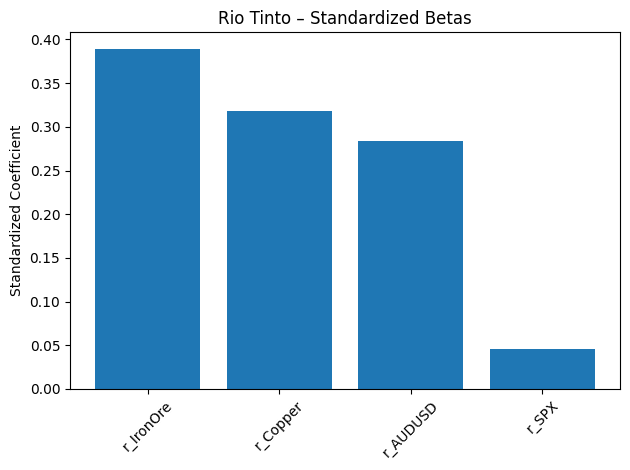

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

std_coef = model_std.params.drop("const")

plt.figure()
plt.bar(std_coef.index, std_coef.values)
plt.title("Rio Tinto – Standardized Betas")
plt.ylabel("Standardized Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Standardized_Betas.png", dpi=300)
plt.show()

In [23]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
file_path = "RioTintoData.xlsx"
# Load the data from the Excel file
df = pd.read_excel(file_path, sheet_name="Monthly_Returns")

for col in df.columns:
    if col != "Month_end":
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.dropna()

print("Sample size after dropna: ", len(df_clean))

X_vif = df_clean[["r_IronOre", "r_Copper", "r_AUDUSD", "r_SPX"]]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

Sample size after dropna:  170
    Variable       VIF
0      const  1.132408
1  r_IronOre  1.205600
2   r_Copper  1.588498
3   r_AUDUSD  1.823210
4      r_SPX  1.476002


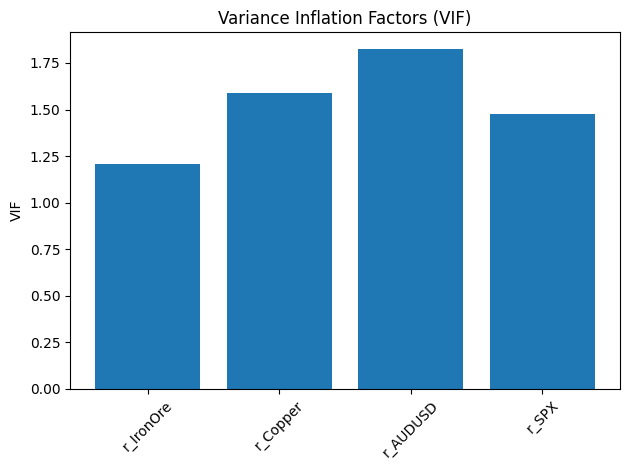

In [30]:
import matplotlib.pyplot as plt

vif_no_const = vif_data[vif_data["Variable"] != "const"]

plt.figure()
plt.bar(vif_no_const["Variable"], vif_no_const["VIF"])
plt.title("Variance Inflation Factors (VIF)")
plt.ylabel("VIF")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("VIF.png", dpi=300)
plt.show()